#  Risk-Based Medical Insurance Pricing  
---

## Project Overview
This project develops a risk-based insurance pricing model to estimate annual medical insurance charges using demographic and lifestyle factors. The solution is designed to support underwriting decisions and pricing consistency, while maintaining explainability suitable for regulated environments.

---
## Problem Statement
Medical insurance costs vary significantly across individuals due to differences in age, lifestyle, and health-related factors. Insurance providers require reliable methods to estimate expected medical charges in order to price policies fairly, manage financial risk, and allocate resources effectively.

---
## Dataset Description
This dataset contains anonymised demographic and lifestyle information used to estimate annual medical insurance charges. The table below summarises the available features and their relevance to insurance pricing.

| Column Name | Data Type | Description | Why It Matters |
|------------|----------|-------------|----------------|
| age | Integer | Age of the primary insurance beneficiary | Medical risk generally increases with age |
| sex | Categorical | Gender of the insurance contractor | Used for demographic analysis and fairness assessment |
| bmi | Float | Body Mass Index | Strong indicator of health-related risk |
| children | Integer | Number of dependents covered | Impacts potential healthcare utilisation |
| smoker | Categorical | Smoking status (yes / no) | One of the strongest drivers of medical insurance costs |
| region | Categorical | Residential region | Captures geographic variation in healthcare pricing |
| charges | Float | Annual medical insurance cost (target variable) | Used for pricing estimation and risk assessment |

---
## Project Objectives
The objectives of this project are to:

- Develop a predictive model to estimate annual medical insurance charges.
- Identify key demographic and lifestyle factors that influence insurance costs.
- Compare interpretable and non-linear modelling approaches.
- Evaluate model performance using appropriate regression diagnostics.
- Prepare the solution for future deployment and reuse.

---
## Project Outcomes

This project delivered the following outcomes:

- A trained and validated machine learning model capable of predicting annual medical insurance charges.
- Identification of key cost drivers, with smoking status, age, and BMI emerging as the most influential factors.
- An interpretable modelling framework supported by regression diagnostics and feature importance analysis.
- A comparative evaluation of Linear Regression and Random Forest models, leading to informed model selection.
- A deployment-ready inference workflow enabling cost estimation for new insurance applicants.

---


## Table of Contents

1. **Import Libraries**

2. **Data Loading**
   - 2.1 Load the Dataset

3. **Exploratory Data Analysis (EDA) – Before Cleaning**
   - 3.1 Dataset Overview
   - 3.2 Data Quality Checks
   - 3.3 Summary Statistics
   - 3.4 Categorical Feature Inspection
   - 3.5 Correlation Analysis (Numeric)

4. **Data Cleaning**
   - 4.1 Duplicate Record Handling
   - 4.2 Data Type Standardisation
   - 4.3 Standardise Categorical Values
   - 4.4 Outlier Assessment
   - 4.5 Final Dataset Validation

5. **Exploratory Data Analysis (EDA) – After Cleaning**
   - 5.1 Univariate Analysis
   - 5.2 Bivariate Analysis
   - 5.3 Multivariate Analysis

6. **Feature Engineering and Preprocessing**
   - 6.1 Feature Selection
   - 6.2 Encode Categorical Variables
   - 6.3 Target Variable Transformation

7. **Modelling**
   - 7.1 Define Features and Target
   - 7.2 Train–Test Split
   - 7.3 Baseline Model (Linear Regression)
   - 7.4 Model Prediction and Evaluation
   - 7.5 Model Evaluation Metrics

   - 7.6 Residual Analysis and Diagnostics (Linear Regression)
     - 7.6.1 Residual Calculation
     - 7.6.2 Residual Distribution (Histogram)
     - 7.6.3 Residual Density (KDE)
     - 7.6.4 Homoscedasticity Check (Residuals vs Predicted Values)
     - 7.6.5 Linearity Check (Actual vs Predicted)
     - 7.6.6 Residual Normality Check (Q–Q Plot)

   - 7.7 Multicollinearity Analysis
     - 7.7.1 Feature-Level VIF
     - 7.7.2 Overall Model VIF
     - 7.7.3 Feature Correlation Heatmap

8. **Ridge Regression Model**

9. **Random Forest Regression Model**
   - 9.1 Model Definition and Training
   - 9.2 Feature Importance Analysis
   - 9.3 Feature Importance Visualisation
   - 9.4 Random Forest Predictions and Evaluation

10. **Model Performance Comparison**

---

## 1. Import Libraries

Import all required Python libraries for data handling, visualisation,
statistical analysis, and machine learning.

In [52]:
# =====================================================
# Data manipulation
# =====================================================
import pandas as pd
import numpy as np
from pathlib import Path

# =====================================================
# Data visualisation
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas

# =====================================================
# Scientific computing & statistics
# =====================================================
import scipy as sp
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =====================================================
# Machine learning: preprocessing
# =====================================================
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# =====================================================
# Machine learning: models
# =====================================================
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# =====================================================
# Model evaluation & metrics
# =====================================================
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =====================================================
# Warnings control
# =====================================================
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


## 2. Data Loading
In this section, we load the insurance cost dataset and perform an initial inspection
to ensure the data has been imported correctly.

### 2.1 Load the Dataset

In [53]:
# File path
data_path = Path("../data/raw/insurance.csv")

# Load the dataset
try:
    df = pd.read_csv(data_path)
except FileNotFoundError:
    raise FileNotFoundError(
        f"Dataset not found at {data_path}. Please check the file location."
    )

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Exploratory Data Analysis (EDA) – Before Cleaning

This section explores and validates the dataset before any cleaning or preprocessing.
The objective is to understand the data structure, variable types, distributions, and
potential data quality issues that may influence modelling decisions.

### 3.1 Dataset Overview

In [54]:
# Dataset dimensions
print("Dataset shape:", df.shape)

# Data types and structure
df.info()

Dataset shape: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### 3.2 Data Quality Checks

In [55]:
print("Missing values:")
df.isnull().sum()

print("\nDuplicate rows:")
df.duplicated().sum()

Missing values:

Duplicate rows:


np.int64(1)

### 3.3 Summary Statistics


In [56]:
# Summary statistics (numeric features)
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [57]:
# Summary statistics (categorical features)
df.describe(include="object")

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


### 3.4 Categorical Feature Inspection

In [58]:
# Unique values in categorical columns
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

sex: ['female' 'male']
smoker: ['yes' 'no']
region: ['southwest' 'southeast' 'northwest' 'northeast']


### 3.5 Correlation Analysis (Numeric)

In [59]:
# Correlation matrix (numeric features)
numeric_cols = df.select_dtypes(include=np.number)
numeric_cols.corr(method="pearson")

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


> **EDA Observations**
> - The dataset contains no missing values or duplicate records.
> - Numeric variables show different ranges and distributions.
> - Categorical variables have low cardinality and are suitable for one-hot encoding.
> - Correlation analysis indicates relationships that will guide feature engineering and model selection.


## 4. Data Cleaning

This section ensures the dataset is consistent and ready for modelling.
Although the dataset is relatively clean, basic validation steps are applied
to confirm data integrity and reproducibility.


### 4.1 Duplicate Record Handling


In [60]:
# Duplicate record handling

# Initial dataset size
initial_rows = df.shape[0]

# Remove duplicate rows (if any)
df = df.drop_duplicates()

# Final dataset size
final_rows = df.shape[0]

print(f"Duplicate rows removed: {initial_rows - final_rows}")


Duplicate rows removed: 1


### 4.2 Data Type Standardisation

In [61]:
# Convert categorical columns to category dtype

categorical_cols = ["sex", "smoker", "region"]

for col in categorical_cols:
    df[col] = df[col].astype("category")

# Verify data types after conversion
df.dtypes

age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object

### 4.3 Standardize Categorical Values 

In [62]:
# Lowercase and strip spaces to maintain consistency

categorical_cols = ["sex", "smoker", "region"]

for col in categorical_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.lower()
        .str.strip()
        .astype("category")
    )

# Verify unique values after standardisation
{col: df[col].unique().tolist() for col in categorical_cols}

{'sex': ['female', 'male'],
 'smoker': ['yes', 'no'],
 'region': ['southwest', 'southeast', 'northwest', 'northeast']}

### 4.4 Outlier Assessment

In [63]:
# Outlier assessment using 99th percentile

numeric_cols = ["age", "bmi", "children", "charges"]

outlier_counts = {
    col: (df[col] > df[col].quantile(0.99)).sum()
    for col in numeric_cols
}

outlier_counts

{'age': np.int64(0),
 'bmi': np.int64(14),
 'children': np.int64(0),
 'charges': np.int64(14)}

### 4.5 Final Dataset Validation

In [64]:
# Final dataset check
df.shape

(1337, 7)

> **Summary:**  The dataset was cleaned by removing duplicate records, standardising data types and categorical values, and assessing potential outliers. No critical data quality issues were identified, and the dataset is suitable for downstream analysis and modelling.


## 5. Exploratory Data Analysis (EDA) – After Cleaning

This section explores the cleaned dataset to validate feature distributions,
understand relationships, and confirm data readiness prior to feature engineering
and modeling.




### 5.1 Univariate Analysis

This section examines the distribution of individual features to identify
skewness, outliers, and data imbalance. Understanding single-variable behavior
helps guide transformations such as scaling or log adjustments.

In [65]:
# Plot styling
sns.set_style("darkgrid")
sns.set_palette("Set2")

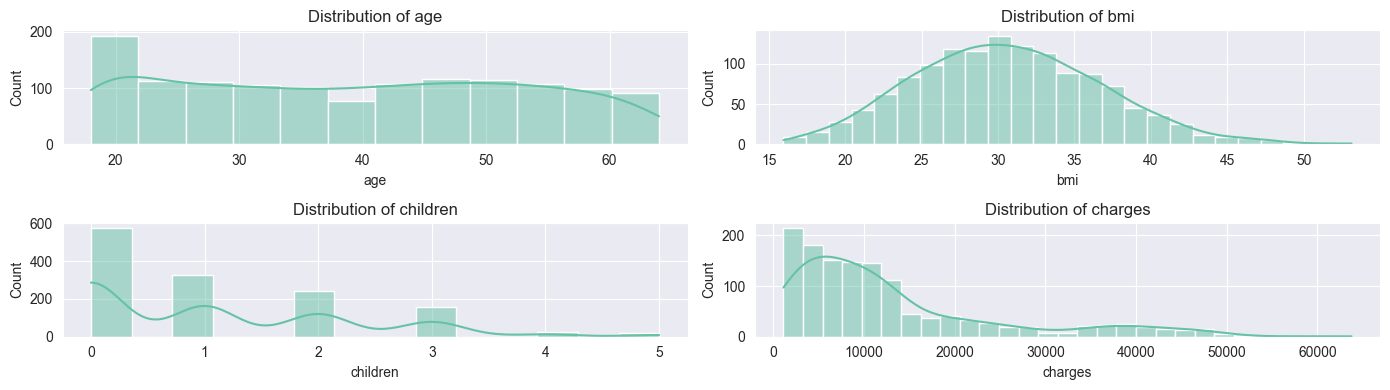

In [66]:
# Numerical Feature Distributions

numeric_cols = ["age", "bmi", "children", "charges"]
plt.figure(figsize=(14,4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

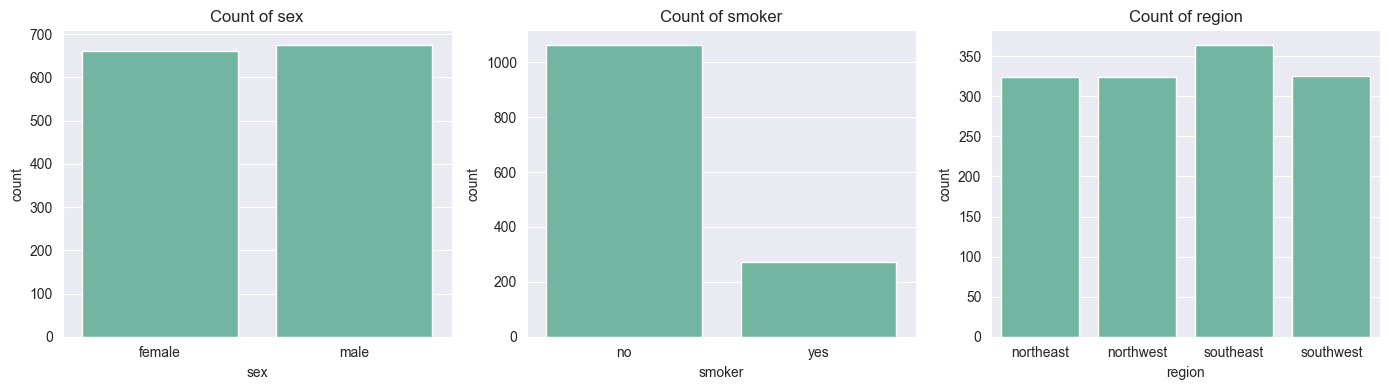

In [67]:
# Categorical Feature Distributions

categorical_cols = ["sex", "smoker", "region"]
plt.figure(figsize=(14,4))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df, x=col)
    plt.title(f"Count of {col}")
    
plt.tight_layout()
plt.show()

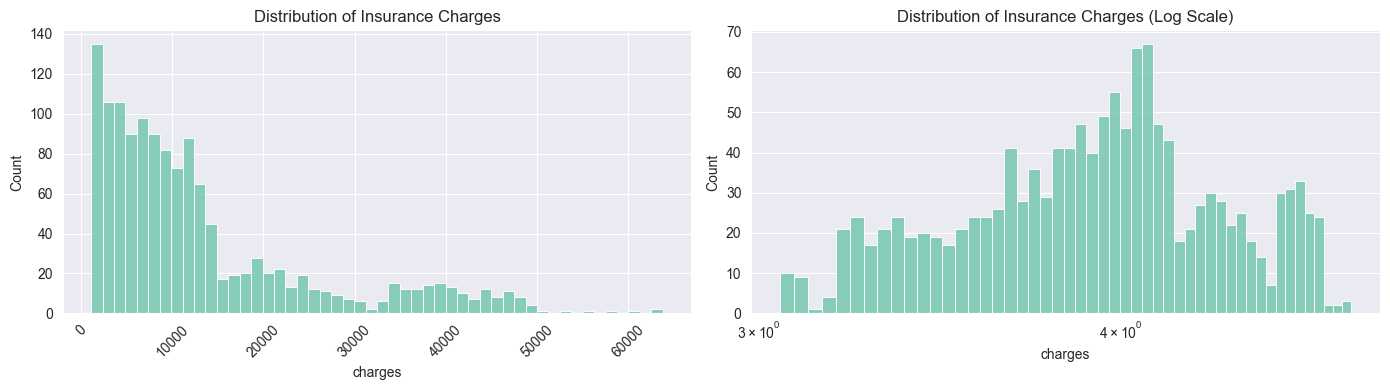

In [68]:
# Distribution of insurance charges in both the original and log-transformed scale

f = plt.figure(figsize=(14, 4))

ax = f.add_subplot(121)
sns.histplot(df["charges"], bins=50, ax=ax)
ax.set_title("Distribution of Insurance Charges")
ax.tick_params(axis="x", rotation=45)

ax = f.add_subplot(122)
sns.histplot(np.log10(df["charges"]), bins=50, ax=ax)
ax.set_title("Distribution of Insurance Charges (Log Scale)")
ax.set_xscale("log")

plt.tight_layout()
plt.show()

> **Key Observations:**  Insurance charges are highly right-skewed, with smoking status, age, and BMI
showing strong associations with higher costs. These observations motivate the
use of a log-transformed target variable and non-linear modelling approaches.


### 5.2 Bivariate Analysis

This section analyzes relationships between individual features and the target
variable (**insurance charges**) to identify key cost drivers and potential
interaction effects.


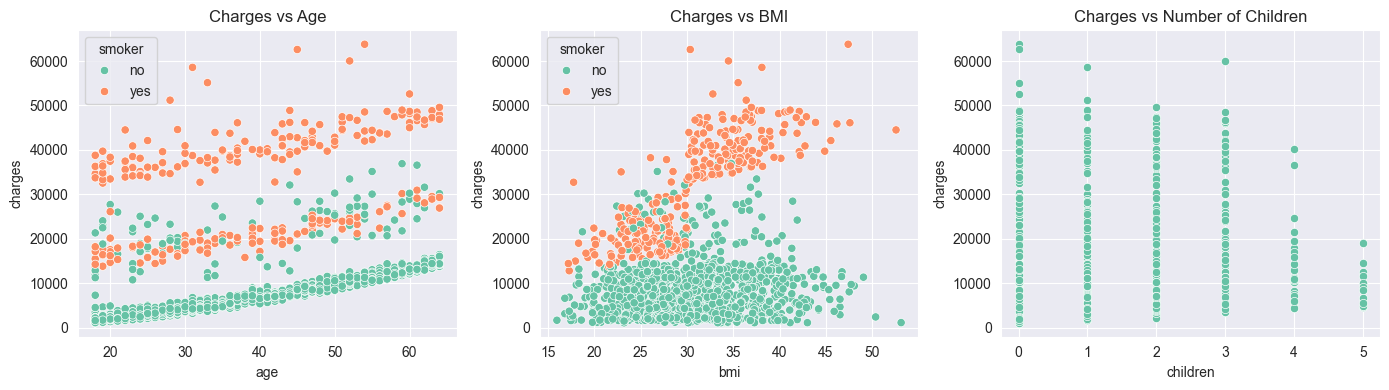

In [69]:
# Charges vs numerical features

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")
plt.title("Charges vs Age")

plt.subplot(1,3,2)
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("Charges vs BMI")

plt.subplot(1,3,3)
sns.scatterplot(data=df, x="children", y="charges")
plt.title("Charges vs Number of Children")

plt.tight_layout()
plt.show()

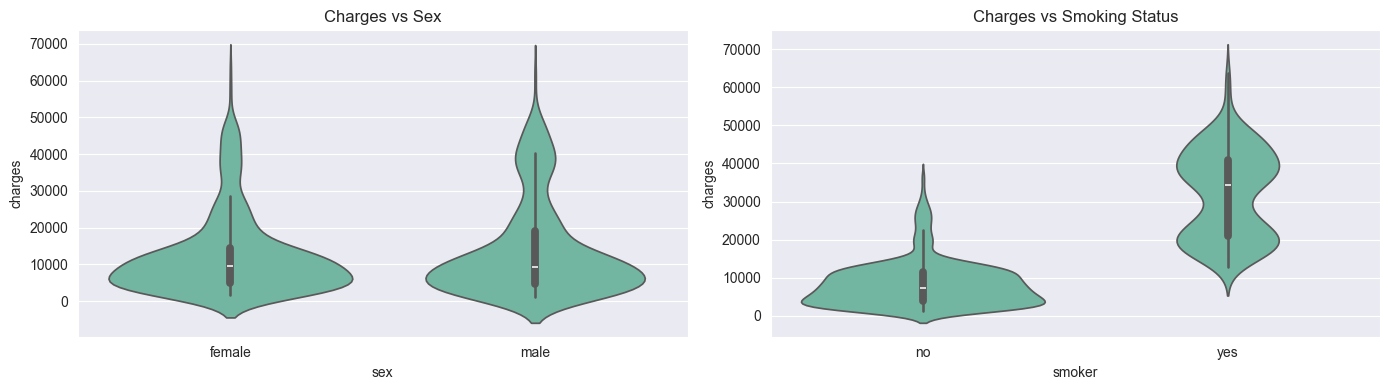

In [70]:
# Charges vs categorical features

plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
sns.violinplot(x="sex", y="charges", data=df)
plt.title("Charges vs Sex")

plt.subplot(1,2,2)
sns.violinplot(x="smoker", y="charges", data=df)
plt.title("Charges vs Smoking Status")

plt.tight_layout()
plt.show()

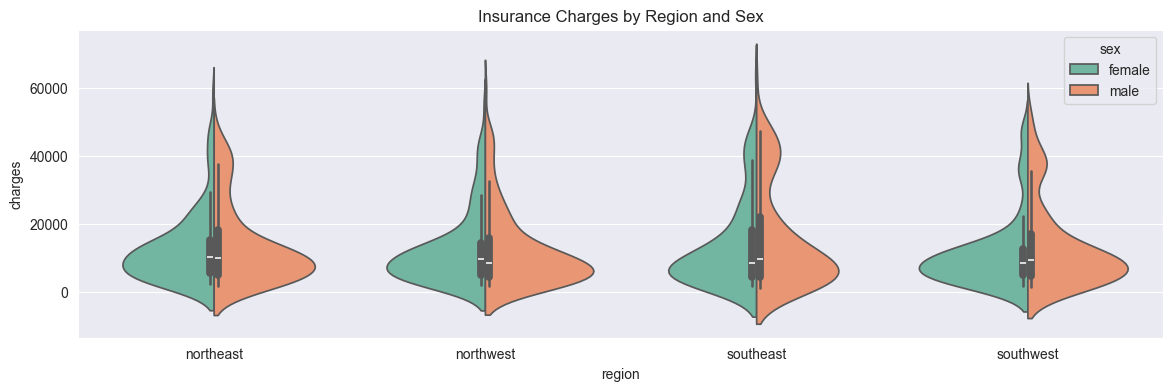

In [71]:
# Charges by region and sex

plt.figure(figsize=(14,4))

sns.violinplot(
    x="region",
    y="charges",
    hue="sex",
    data=df,
    split=True
)
plt.title("Insurance Charges by Region and Sex")
plt.show()

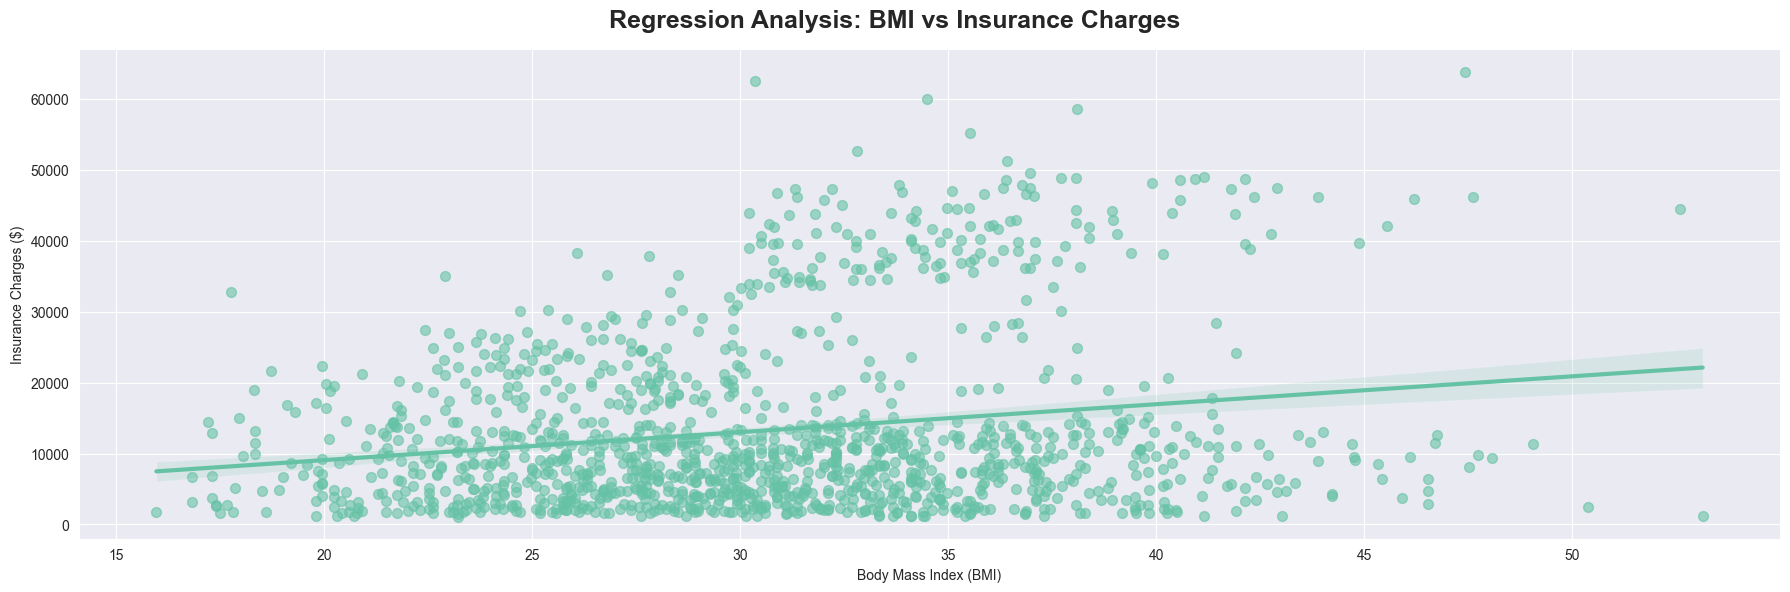

In [72]:
# Regression analysis: BMI vs charges

g = sns.lmplot(
    x="bmi",
    y="charges",
    data=df,
    scatter_kws={"alpha": 0.6, "s": 50},
    line_kws={"linewidth": 3},
    aspect=3,
    height=6
)

g.set_axis_labels("Body Mass Index (BMI)", "Insurance Charges ($)")
g.fig.suptitle(
    "Regression Analysis: BMI vs Insurance Charges",
    fontsize=18,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

> **Key Observations:** 
Insurance charges are most strongly influenced by smoking status, with age and BMI further amplifying costs, particularly among smokers. Other factors such as sex, number of children, and region show comparatively weaker direct relationships with insurance charges.

### 5.3 Multivariate Analysis

This section explores interactions among multiple numerical variables to
identify correlated features and patterns that may influence feature engineering
and model selection.


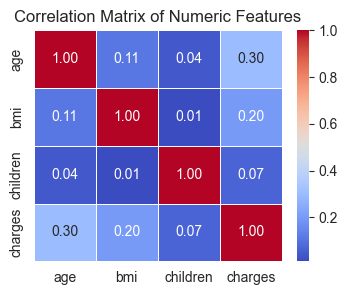

In [73]:
# Correlation analysis (numeric features)

numeric_cols = ["age", "bmi", "children", "charges"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(4,3))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    linecolor='white',
    fmt=".2f"
)

plt.title("Correlation Matrix of Numeric Features")
plt.show()

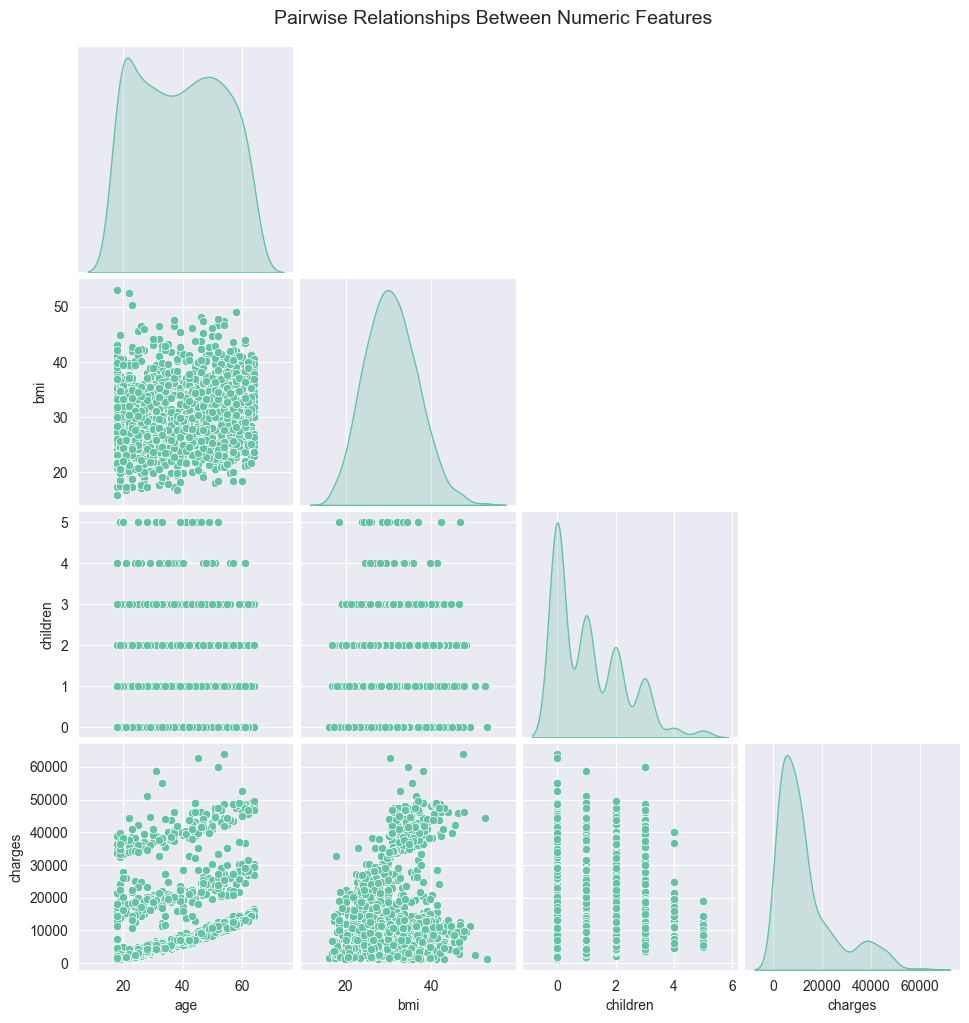

In [74]:
# Pairplot for numeric features

sns.pairplot(
    df[numeric_cols],
    diag_kind="kde",
    corner=True
)
plt.suptitle(
    "Pairwise Relationships Between Numeric Features",
    y=1.02,
    fontsize=14
)
plt.show()

## 6. Feature Engineering and Preprocessing

This section prepares the dataset for modeling by selecting relevant features,
encoding categorical variables, and applying transformations to improve model
performance and stability.


### 6.1 Feature Selection

In [75]:
# Drop the 'region' feature as it is not required for the current analysis

df2 = df.drop(columns=["region"])

### 6.2 Encode Categorical Variables

In [76]:
# One-hot encoding for categorical features

categorical_cols = ["sex", "children", "smoker"]

df_encoded = pd.get_dummies(
    data=df2,
    columns=categorical_cols,
    drop_first=True,
    dtype="int8"
)

# Compare feature dimensions before and after encoding
print("Original feature shape:", df.shape)
print("Encoded feature shape :", df_encoded.shape)

df_encoded.head()

Original feature shape: (1337, 7)
Encoded feature shape : (1337, 10)


,age,bmi,charges,sex_male,children_1,children_2,children_3,children_4,children_5,smoker_yes
0,19,27.900,16884.92400,0,0,0,0,0,0,1
1,18,33.770,1725.55230,1,1,0,0,0,0,0
2,28,33.000,4449.46200,1,0,0,1,0,0,0
3,33,22.705,21984.47061,1,0,0,0,0,0,0
4,32,28.880,3866.85520,1,0,0,0,0,0,0


### 6.3 Target Variable Transformation

In [77]:
# Log transformation of target variable

df_encoded["charges"] = np.log(df_encoded["charges"])
df_encoded["charges"].head()


0    9.734176
1    7.453302
2    8.400538
3    9.998092
4    8.260197
Name: charges, dtype: float64

## 7. Modelling

This section builds baseline regression models to predict medical insurance
charges and establishes a performance benchmark for comparison with more
advanced models.


### 7.1 Define Features and Target

In [78]:
# Define features and target

X = df_encoded.drop(columns=["charges"])
y = df_encoded["charges"]  # log-transformed target

print("Feature matrix shape:", X.shape)
print("Target vector shape :", y.shape)


Feature matrix shape: (1337, 9)
Target vector shape : (1337,)


### 7.2 Train–Test Split

In [79]:
# Train–Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=23
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((935, 9), (402, 9), (935,), (402,))

### 7.3 Baseline Model (Linear Regression)

In [80]:
# Train Linear Regression model

lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)
print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 7.4 Model Prediction and Evaluation


In [81]:
# Make predictions (log-transformed scale)

y_pred_log = lin_reg_model.predict(X_test)
print("Predictions generated successfully.")

Predictions generated successfully.


In [82]:
# Model performance (R² score)

r2 = r2_score(y_test, y_pred_log)
print("R² score (log scale):", round(r2, 4))

R² score (log scale): 0.7813


### 7.5 Model Evaluation Metrics


In [83]:
# This section evaluates the predictive performance of the trained regression model using standard regression metrics.

def evaluate_regression_model(y_test, y_pred_log):
   
    r2   = r2_score(y_test, y_pred_log)
    mae  = mean_absolute_error(y_test, y_pred_log)
    mse  = mean_squared_error(y_test, y_pred_log)
    rmse = np.sqrt(mse)

    print("Model Evaluation Metrics")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")

    return r2, mae, mse, rmse

In [84]:
lin_metrics = evaluate_regression_model(y_test, y_pred_log)

Model Evaluation Metrics
R²   : 0.7813
MAE  : 0.29
MSE  : 0.19
RMSE : 0.44


### 7.6 Residual Analysis and Diagnostics (Linear Regression)

This section evaluates whether the core assumptions of Linear Regression are reasonably satisfied. Residual-based diagnostic checks are performed to assess distributional behavior, variance stability, linearity, multicollinearity, and normality. Together, these diagnostics help validate the reliability and interpretability of the model.

The following diagnostic checks are conducted:

- **Residual Distribution**  
  Examines whether residuals are centered around zero and symmetrically
  distributed.

- **Homoscedasticity**  
  Assesses whether residual variance remains constant across fitted values.

- **Linearity**  
  Evaluates whether the relationship between predictors and the target is
  approximately linear.

- **Multicollinearity (VIF)**  
  Identifies correlated predictors that may inflate coefficient variance and
  reduce interpretability.

- **Residual Normality**  
  Checks whether residuals follow an approximately normal distribution, which
  supports reliable statistical inference.

### 7.6.1 Residual Calculation




In [85]:
# Residuals represent the difference between observed values and model predictions.
residuals = y_test - y_pred_log

# Inspect residuals
print("Residuals shape:", residuals.shape)
display(pd.DataFrame({"Residuals": residuals}).head())

Residuals shape: (402,)


,Residuals
634,-0.119674
1198,-0.030166
207,-0.280829
714,-0.298421
616,0.110961


> **Interpretation:** Residuals quantify model error. Analyzing their behavior helps determine whether the linear regression assumptions are violated.

### 7.6.2 Residual Distribution (Histogram)

This plot examines whether residuals are centered around zero and symmetrically distributed.


In [86]:
# This plot examines whether residuals are centered around zero and symmetrically distributed.

residual_df = pd.DataFrame({"Residuals": residuals})

residual_df.hvplot.hist(
    bins=25,
    alpha=0.6,
    title="Residual Distribution (Histogram)",
    xlabel="Residual Value",
    ylabel="Frequency"
)


:Histogram   [Residuals]   (Count)

>**Interpretation:**
A roughly symmetric distribution centered near zero suggests that the model does not systematically over or under predict. Mild skewness is acceptable for large samples.

### 7.6.3 Residual Density (KDE)


In [87]:
# Kernel Density Estimation provides a smooth view of residual distribution.

residual_df.hvplot.kde(
    title="Residual Density (KDE)",
    xlabel="Residual Value"
)

:Distribution   [Residuals]   (Density)

> **Interpretation:**  A single bell-shaped peak centered near zero supports the assumption of unbiased residuals and approximate normality.


### 7.6.4 Homoscedasticity Check (Residuals vs Predicted Values)

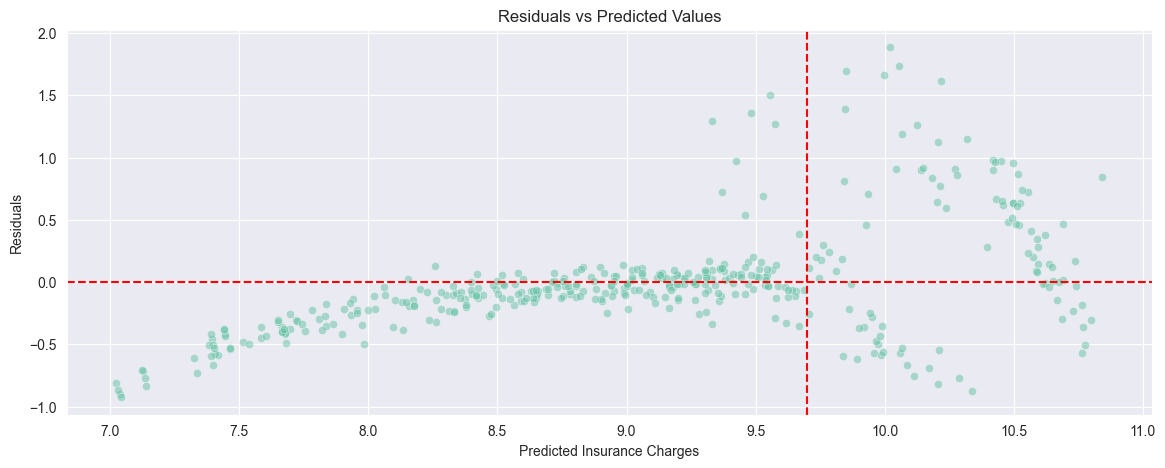

In [88]:
# This plot assesses whether residual variance remains constant across predicted values.

plt.figure(figsize=(14,5))

sns.scatterplot(x=y_test, y=residuals, alpha=0.5)

# Reference line at zero residual
plt.axhline(y=0, color='red', linestyle='--')
plt.axvline(x=9.7, color='red', linestyle='--');

plt.xlabel("Predicted Insurance Charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

> **Interpretation**:
A random scatter of points around zero with no visible funnel or pattern indicates homoscedasticity. This suggests stable error variance across prediction levels.

### 7.6.5 Linearity Check (Actual vs Predicted)

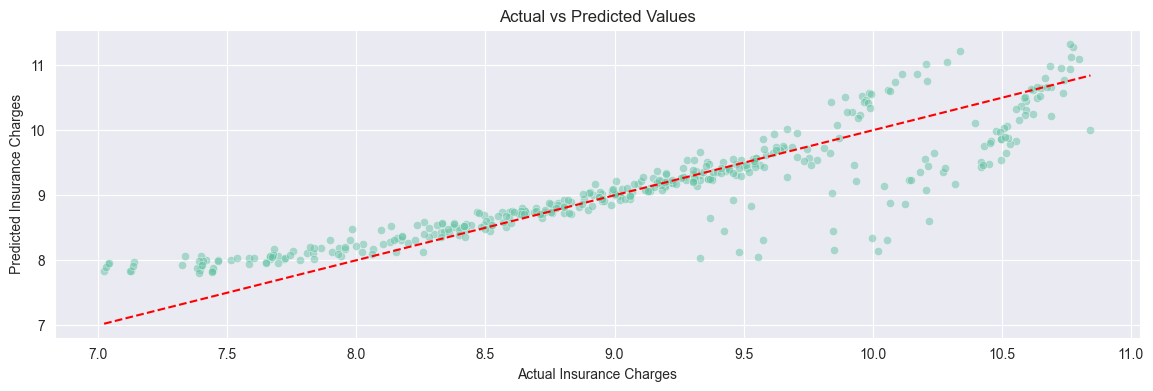

In [89]:
# This plot evaluates whether the relationship between predictors and the target is approximately linear.

plt.figure(figsize=(14,4))
sns.scatterplot(x=y_test, y=y_pred_log, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Insurance Charges")
plt.ylabel("Predicted Insurance Charges")
plt.title("Actual vs Predicted Values")
plt.show()

> **Interpretation**:
Points closely aligned with the diagonal reference line indicate that the linear model captures the underlying relationship reasonably well.

### 7.6.6 Residual Normality Check (Q–Q Plot)

A Q–Q plot (Quantile–Quantile plot) is used to assess whether model residuals follow an approximately normal distribution, which is a key assumption for statistical inference in Linear Regression (e.g., confidence intervals and hypothesis tests).

**Q–Q Plot Output Parameters**

| Parameter | Description                            | What It Tells You                                                |
| --------- | -------------------------------------- | ---------------------------------------------------------------- |
| `a[0]`    | Theoretical quantiles                  | Expected values from a normal distribution                       |
| `a[1]`    | Ordered residuals (sorted sample data) | Actual residual values from the model                            |
| `b`       | Slope of fitted reference line         | Detects scale mismatch between residuals and normal distribution |
| `c`       | Intercept of fitted reference line     | Detects location shift (mean offset from zero)                   |
| `r`       | **Q–Q correlation coefficient**        | Measures how closely residuals follow a normal distribution      |



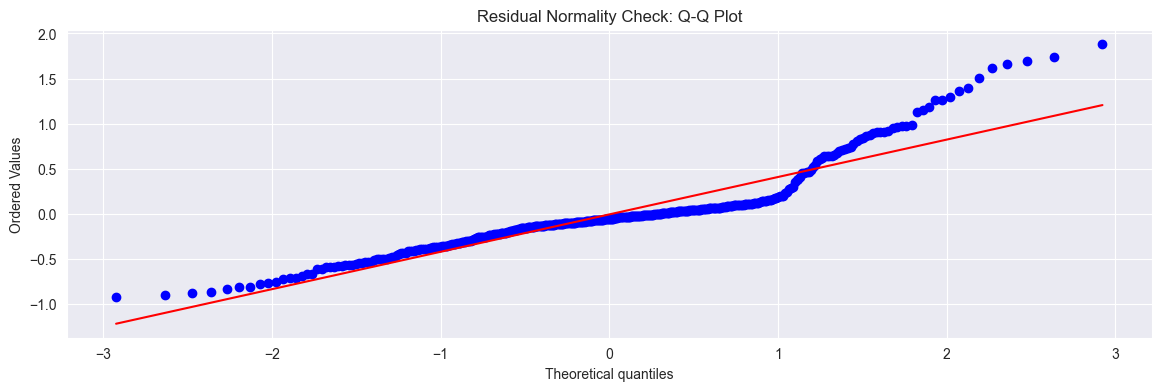

In [90]:
f, ax = plt.subplots(1, 1, figsize=(14, 4))
a, (b,c,r) = sp.stats.probplot((residuals), fit = True, plot=ax)
ax.set_title('Residual Normality Check: Q-Q Plot')
plt.show()

> **Interpretation:**
If residuals follow a straight diagonal line, normality is reasonably satisfied. Minor deviations at the tails are common and generally acceptable for regression inference.

### 7.7 Multicollinearity Analysis
Variance Inflation Factor (VIF) is used to assess multicollinearity among predictor variables.
High VIF values indicate strong linear dependence between features, which can inflate
coefficient variance and reduce interpretability.

As a general guideline:
- VIF < 5  → low multicollinearity (Acceptable)
- VIF ≥ 5  → potential multicollinearity concern

### 7.7.1 Feature-Level VIF

Variance Inflation Factor (VIF) measures multicollinearity among predictors.

Feature-level VIF 
This computes the Variance Inflation Factor for each predictor individually. 
High VIF values indicate strong correlation between predictors, which can inflate 
coefficient variance and reduce interpretability.

In [91]:
X_vif = sm.add_constant(X_train)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data.sort_values("VIF", ascending=False)

,Feature,VIF
0,const,33.950681
4,children_1,1.182212
5,children_2,1.156988
6,children_3,1.127589
7,children_4,1.023858
8,children_5,1.023135
2,bmi,1.016697
1,age,1.012260
9,smoker_yes,1.010980
3,sex_male,1.010653


> **Interpretation:**
Low to moderate VIF values indicate that predictors are not strongly correlated, supporting coefficient stability and interpretability.

### 7.7.2 Overall Model VIF

In [92]:
R_square = lin_reg_model.score(X_train, y_train)
VIF_overall = 1 / (1 - R_square)
print(f"Overall Model VIF: {VIF_overall:.4f}")

Overall Model VIF: 4.1207


> **Interpretation:** The overall VIF provides a rough indication of multicollinearity at the model level. Moderate values suggest acceptable redundancy among predictors.

### 7.7.3 Feature Correlation Heatmap

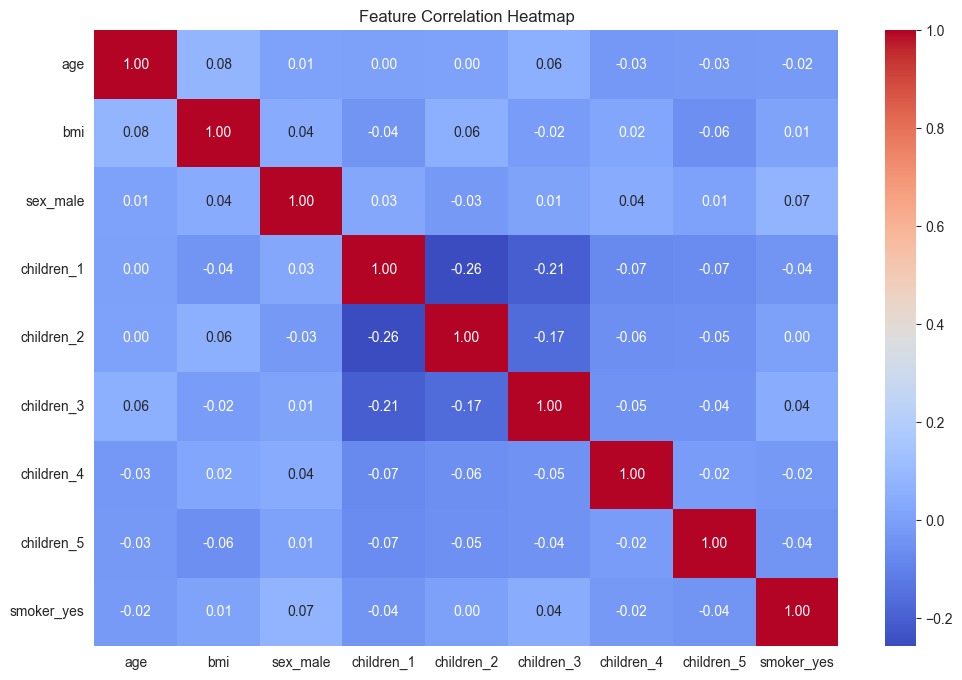

In [93]:
plt.figure(figsize=(12,8))
sns.heatmap(
    X_train.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Feature Correlation Heatmap")
plt.show()

## 8. Ridge Regression Model 

Ridge Regression is a regularized extension of Linear Regression that applies L2 penalty to shrink coefficient magnitudes. It is particularly useful when multicollinearity is present, as it stabilizes coefficient estimates while preserving all predictors.

In this analysis, Ridge Regression is used to validate whether multicollinearity materially impacts model performance, following the VIF and correlation heatmap analysis in Section 7.7.

In [94]:
# Define Ridge model
ridge = Ridge(random_state=23)

# Hyperparameter grid
alpha_grid = {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}

# Cross-validated Ridge Regression
ridge_cv = GridSearchCV(
    estimator=ridge,
    param_grid=alpha_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train Ridge model
ridge_cv.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_cv.best_params_["alpha"])

Best Ridge alpha: 1.0


In [95]:
# Predictions (log scale)
y_pred_log_ridge = ridge_cv.predict(X_test)

In [96]:
# Evaluate Ridge Regression performance
ridge_metrics = evaluate_regression_model(y_test, y_pred_log_ridge)

Model Evaluation Metrics
R²   : 0.7813
MAE  : 0.29
MSE  : 0.19
RMSE : 0.44


> **Ridge Regression Interpretation:** Ridge regression produced nearly identical performance metrics to the baseline
Linear Regression model. This indicates that while some multicollinearity exists
among numerical features, it does not materially impact predictive performance.
Ridge therefore serves as a confirmatory diagnostic rather than a performance
improvement in this case.


## 9. Random Forest Regression Model

Random Forest is an ensemble, tree-based model that captures non-linear relationships and feature interactions without relying on linearity or distributional assumptions. It serves as a strong benchmark against linear and regularized models.

### 9.1 Model Definition and Training

In [97]:
rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### 9.2 Feature Importance Analysis

In [98]:
# Random Forest provides model-based feature importance, indicating each feature’s relative contribution to prediction accuracy.

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
8,smoker_yes,0.480477
0,age,0.383620
1,bmi,0.091887
4,children_2,0.012148
2,sex_male,0.009422
5,children_3,0.008699
3,children_1,0.007084
6,children_4,0.005356
7,children_5,0.001306


### 9.3 Feature Importance Visualization

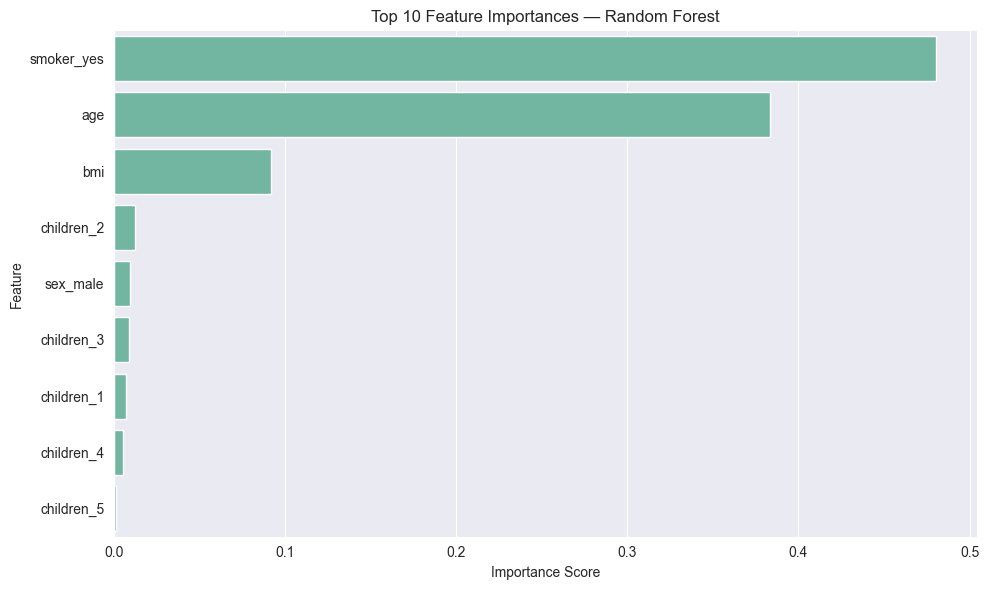

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


> **Interpretation:**  
Smoking status is the strongest predictor of insurance charges, followed by age and BMI.
This aligns with domain expectations, as smoking and higher BMI are associated with
increased health risk and medical costs. Tree-based models capture these non-linear
effects and interactions more effectively than linear regression.


### 9.4 Random Forest Predictions and Evaluation

In [100]:
# Random Forest predictions & evaluation

# Predict in log space
y_log_pred_rf = rf_model.predict(X_test)

# Inverse transform to original scale
#y_pred_rf = np.expm1(y_log_pred_rf)

# Evaluate Random Forest
rf_metrics = evaluate_regression_model(y_test, y_log_pred_rf)



Model Evaluation Metrics
R²   : 0.8239
MAE  : 0.23
MSE  : 0.16
RMSE : 0.40


> **Interpretation:**
Random Forest typically achieves stronger predictive performance by capturing complex patterns that linear models cannot.

## 10 Model Performance Comparison

In [101]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Random Forest"],
    "R²":   [lin_metrics[0], ridge_metrics[0], rf_metrics[0]],
    "MAE":  [lin_metrics[1], ridge_metrics[1], rf_metrics[1]],
    "MSE":  [lin_metrics[2], ridge_metrics[2], rf_metrics[2]],
    "RMSE": [lin_metrics[3], ridge_metrics[3], rf_metrics[3]],
})

comparison_df


,Model,R²,MAE,MSE,RMSE
0,Linear Regression,0.781264,0.290206,0.194395,0.440903
1,Ridge Regression,0.781257,0.290011,0.194401,0.440910
2,Random Forest,0.823936,0.225950,0.156472,0.395566


### 10.1 Model Comparison Conclusion

Ridge Regression produced nearly identical results to the baseline Linear Regression model, confirming that multicollinearity does not significantly impact predictive performance. Random Forest outperformed both linear models across all evaluation metrics, indicating the presence of non-linear relationships and feature interactions.

While Random Forest offers superior accuracy, Linear and Ridge models remain valuable for interpretability. Final model selection therefore depends on the trade-off between predictive performance and explainability.

## Conclusion:
Smoking status is the primary cost driver, with age and BMI contributing non-linear effects. Linear Regression offers interpretability, while Random Forest enhances predictive accuracy, demonstrating a robust end-to-end machine learning workflow.
